# Feature Divergence Analysis: Full Window Baseline

**Purpose**: Analyze ALL physiological features (pupil, gaze, EEG) across the full PRE-decision window to establish baseline effect sizes for INVEST vs KEEP decisions.

**Method**:
- Use already-extracted features (full window aggregates)
- Compare INVEST vs KEEP decisions
- Statistical tests (t-tests, Cohen's d effect sizes)
- Bonferroni correction for multiple comparisons

**Modalities**:
- **Pupil**: 13 features (size, dynamics, variability)
- **Gaze**: 20 features (position, velocity, fixations)
- **EEG**: 16 features (band power × brain region)

This notebook provides the baseline against which temporal dynamics can be compared.

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/feature_divergence')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"FEATURE DIVERGENCE ANALYSIS: FULL WINDOW BASELINE")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

FEATURE DIVERGENCE ANALYSIS: FULL WINDOW BASELINE
Analysis started: 2026-04-17 12:07:03


## 1. Load All Features

In [2]:
# Load pupil, gaze, behavior features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']  # Pupil features
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Pupil (physio): {len(physio_cols)}")
print(f"  Gaze: {len(gaze_cols)}")
print(f"  Behavior: {len(behavior_cols)}")

# Load EEG features
try:
    with open('../../data/features/eeg_features.pkl', 'rb') as f:
        eeg_data = pickle.load(f)
    eeg_df = eeg_data['eeg_features_df']
    eeg_cols = eeg_data['feature_columns']
    
    # Merge EEG with main dataframe
    merged_with_eeg = merged_df.merge(eeg_df[['trial_id'] + eeg_cols], on='trial_id', how='inner')
    print(f"  EEG: {len(eeg_cols)} (available for {len(merged_with_eeg)} trials)")
    HAS_EEG = True
except FileNotFoundError:
    print("  EEG: Not available")
    merged_with_eeg = None
    eeg_cols = []
    HAS_EEG = False

print(f"\nOutcome distribution:")
print(merged_df['outcome'].value_counts())

Loaded 12107 trials from 102 subjects

Feature counts:
  Pupil (physio): 13
  Gaze: 20
  Behavior: 11
  EEG: 16 (available for 9922 trials)

Outcome distribution:
outcome
1    7910
0    4197
Name: count, dtype: int64


## 2. Statistical Analysis Functions

In [3]:
def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std


def analyze_feature_divergence(df, feature_cols, modality_name):
    """
    Compute divergence statistics for all features in a modality.
    
    Returns DataFrame with effect sizes, p-values, and significance.
    """
    invest_df = df[df['outcome'] == 1]
    keep_df = df[df['outcome'] == 0]
    
    results = []
    for col in feature_cols:
        if col not in df.columns:
            continue
            
        invest_vals = invest_df[col].dropna()
        keep_vals = keep_df[col].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        # T-test
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        
        # Effect size
        cohens_d = compute_cohens_d(invest_vals, keep_vals)
        
        results.append({
            'modality': modality_name,
            'feature': col,
            'invest_mean': invest_vals.mean(),
            'invest_std': invest_vals.std(),
            'keep_mean': keep_vals.mean(),
            'keep_std': keep_vals.std(),
            'difference': invest_vals.mean() - keep_vals.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'n_invest': len(invest_vals),
            'n_keep': len(keep_vals)
        })
    
    return pd.DataFrame(results)

print("Analysis functions defined")

Analysis functions defined


## 3. Analyze Each Modality

In [4]:
# Analyze pupil features
pupil_results = analyze_feature_divergence(merged_df, physio_cols, 'pupil')
print(f"Pupil: {len(pupil_results)} features analyzed")

# Analyze gaze features
gaze_results = analyze_feature_divergence(merged_df, gaze_cols, 'gaze')
print(f"Gaze: {len(gaze_results)} features analyzed")

# Analyze EEG features (if available)
if HAS_EEG:
    eeg_results = analyze_feature_divergence(merged_with_eeg, eeg_cols, 'eeg')
    print(f"EEG: {len(eeg_results)} features analyzed")
else:
    eeg_results = pd.DataFrame()

# Combine all results
all_results = pd.concat([pupil_results, gaze_results, eeg_results], ignore_index=True)

# Add multiple comparison correction
n_tests = len(all_results)
all_results['significant_uncorrected'] = all_results['p_value'] < 0.05
all_results['significant_bonferroni'] = all_results['p_value'] < (0.05 / n_tests)

# FDR correction (Benjamini-Hochberg)
sorted_pvals = all_results['p_value'].sort_values()
fdr_threshold = 0.05 * np.arange(1, n_tests + 1) / n_tests
fdr_significant = sorted_pvals.values <= fdr_threshold
if fdr_significant.any():
    max_idx = np.where(fdr_significant)[0][-1]
    fdr_cutoff = sorted_pvals.iloc[max_idx]
else:
    fdr_cutoff = 0
all_results['significant_fdr'] = all_results['p_value'] <= fdr_cutoff

print(f"\nTotal features: {n_tests}")
print(f"Significant (p < 0.05): {all_results['significant_uncorrected'].sum()}")
print(f"Significant (Bonferroni): {all_results['significant_bonferroni'].sum()}")
print(f"Significant (FDR): {all_results['significant_fdr'].sum()}")

Pupil: 13 features analyzed
Gaze: 20 features analyzed
EEG: 16 features analyzed

Total features: 49
Significant (p < 0.05): 34
Significant (Bonferroni): 21
Significant (FDR): 32


## 4. Results Summary by Modality

In [5]:
print("\n" + "="*90)
print("FEATURE DIVERGENCE RESULTS BY MODALITY")
print("="*90)

for modality in ['pupil', 'gaze', 'eeg']:
    mod_df = all_results[all_results['modality'] == modality]
    
    if len(mod_df) == 0:
        continue
    
    print(f"\n{'='*50}")
    print(f"  {modality.upper()} FEATURES")
    print(f"{'='*50}")
    print(f"Total features: {len(mod_df)}")
    print(f"Significant (uncorrected): {mod_df['significant_uncorrected'].sum()}")
    print(f"Significant (Bonferroni): {mod_df['significant_bonferroni'].sum()}")
    
    # Top effects
    print(f"\nTop 10 features by effect size:")
    top = mod_df.sort_values('abs_cohens_d', ascending=False).head(10)
    print(top[['feature', 'cohens_d', 'p_value', 'significant_bonferroni']].to_string(index=False))


FEATURE DIVERGENCE RESULTS BY MODALITY

  PUPIL FEATURES
Total features: 13
Significant (uncorrected): 10
Significant (Bonferroni): 9

Top 10 features by effect size:
                        feature  cohens_d      p_value  significant_bonferroni
                pupil_slope_pre -0.302575 5.617779e-56                    True
                  pupil_std_pre  0.239539 7.218312e-36                    True
          pct_time_dilating_pre -0.199459 1.988332e-25                    True
               time_to_peak_pre -0.160002 5.952220e-17                    True
        pupil_velocity_mean_pre  0.148398 8.426725e-15                    True
         num_dilation_peaks_pre -0.147962 1.007826e-14                    True
pupil_max_constriction_rate_pre  0.126618 3.491985e-11                    True
                 pupil_mean_pre  0.103318 6.414664e-08                    True
     pupil_acceleration_std_pre  0.070888 2.065404e-04                    True
    pupil_max_dilation_rate_pre -0.045759 

## 5. Effect Size Visualization

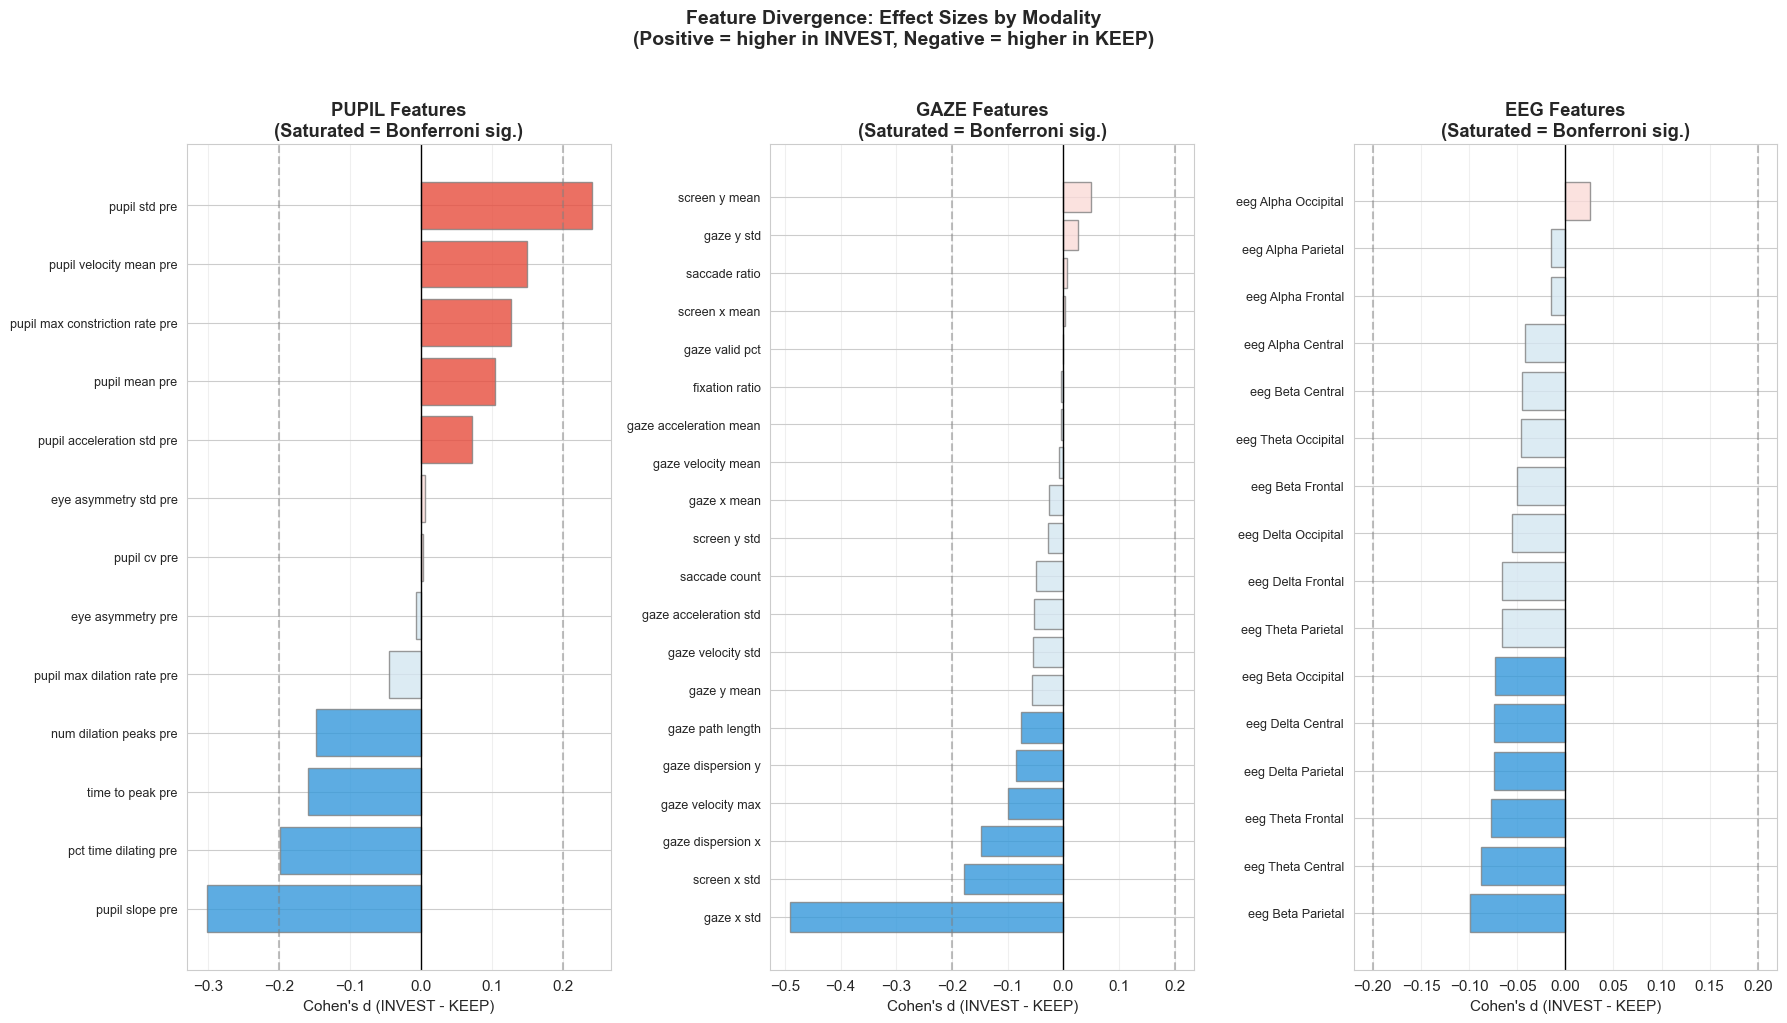

In [6]:
# Create effect size heatmap by modality
n_modalities = all_results['modality'].nunique()
fig, axes = plt.subplots(1, n_modalities, figsize=(6*n_modalities, 10))

if n_modalities == 1:
    axes = [axes]

for idx, modality in enumerate(['pupil', 'gaze', 'eeg']):
    mod_df = all_results[all_results['modality'] == modality].copy()
    
    if len(mod_df) == 0:
        continue
    
    ax = axes[idx]
    
    # Sort by effect size
    mod_df = mod_df.sort_values('cohens_d', ascending=True)
    
    # Color by direction and significance
    colors = []
    for _, row in mod_df.iterrows():
        if row['significant_bonferroni']:
            colors.append('#E74C3C' if row['cohens_d'] > 0 else '#3498DB')
        else:
            colors.append('#FADBD8' if row['cohens_d'] > 0 else '#D4E6F1')
    
    y_pos = range(len(mod_df))
    ax.barh(y_pos, mod_df['cohens_d'], color=colors, edgecolor='gray', alpha=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mod_df['feature'].apply(lambda x: x.replace('_', ' ')), fontsize=9)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.5, label='Small effect')
    ax.axvline(x=-0.2, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("Cohen's d (INVEST - KEEP)")
    ax.set_title(f'{modality.upper()} Features\n(Saturated = Bonferroni sig.)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Divergence: Effect Sizes by Modality\n(Positive = higher in INVEST, Negative = higher in KEEP)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'effect_sizes_by_modality.png', dpi=300, bbox_inches='tight')
plt.show()

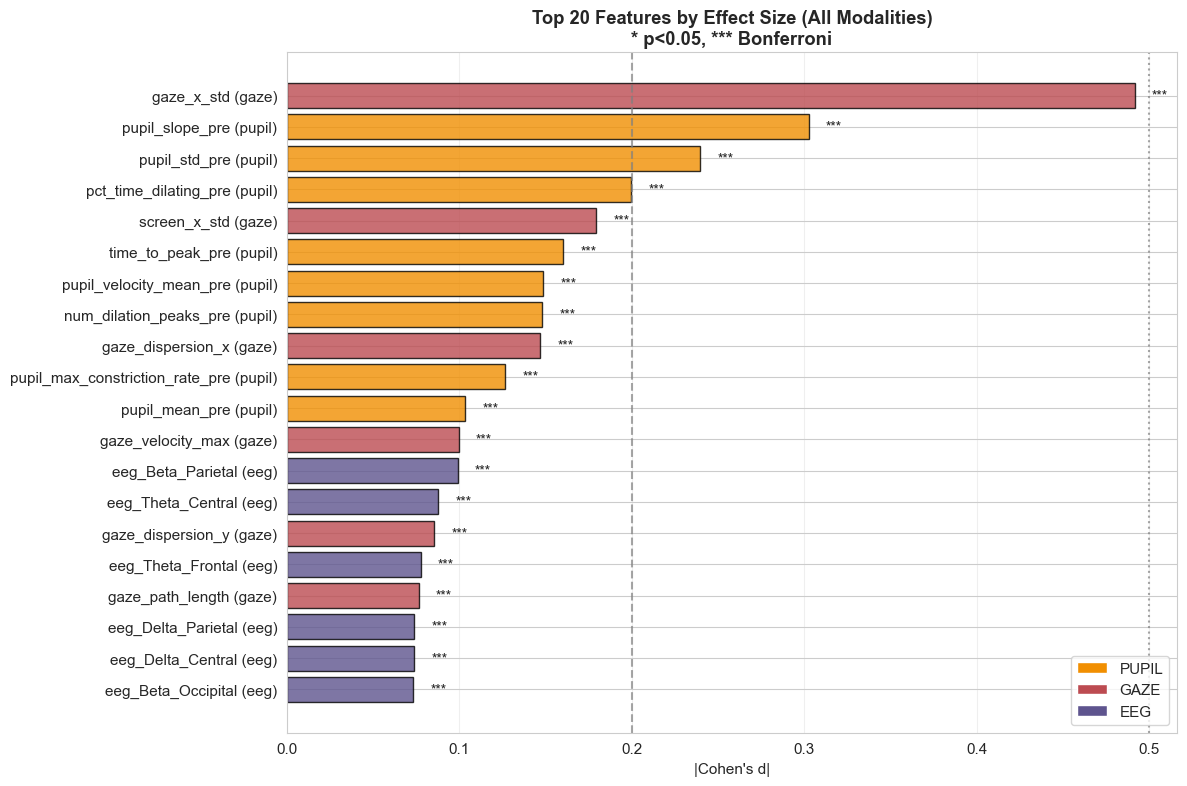

In [7]:
# Overall top features across all modalities
top_overall = all_results.sort_values('abs_cohens_d', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))

colors = {'pupil': '#F18F01', 'gaze': '#BC4B51', 'eeg': '#5E548E'}
bar_colors = [colors[m] for m in top_overall['modality']]

y_pos = range(len(top_overall))
ax.barh(y_pos, top_overall['abs_cohens_d'], color=bar_colors, alpha=0.8, edgecolor='black')

# Add significance markers
for i, (_, row) in enumerate(top_overall.iterrows()):
    marker = '***' if row['significant_bonferroni'] else ('*' if row['significant_uncorrected'] else '')
    ax.text(row['abs_cohens_d'] + 0.01, i, marker, va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['feature']} ({row['modality']})" for _, row in top_overall.iterrows()])
ax.invert_yaxis()
ax.set_xlabel("|Cohen's d|")
ax.set_title('Top 20 Features by Effect Size (All Modalities)\n* p<0.05, *** Bonferroni', fontweight='bold')
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.7, label='Small effect (0.2)')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Medium effect (0.5)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

# Add legend for modality colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m.upper()) for m, c in colors.items() if m in top_overall['modality'].values]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_features_all_modalities.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Modality Comparison Summary


MODALITY COMPARISON SUMMARY
          N Features  Mean |d|  Max |d|  Sig (p<0.05)  Sig (Bonf)
modality                                                         
eeg               16     0.057    0.099            13           6
gaze              20     0.072    0.492            11           6
pupil             13     0.120    0.303            10           9


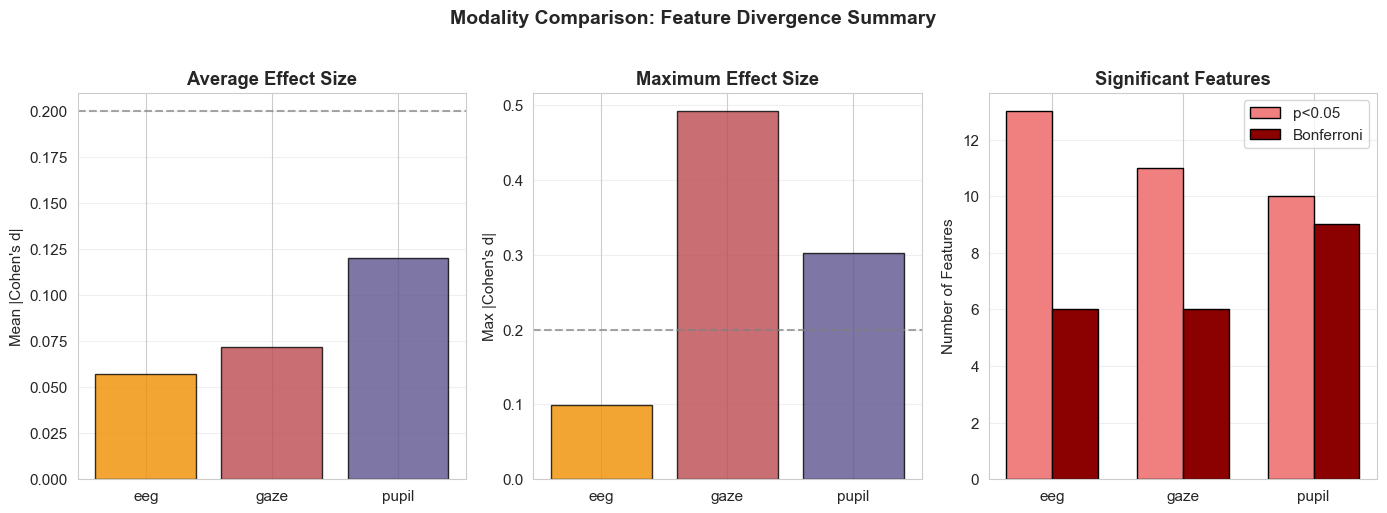

In [8]:
# Summary statistics by modality
summary_stats = all_results.groupby('modality').agg({
    'feature': 'count',
    'abs_cohens_d': ['mean', 'max'],
    'significant_uncorrected': 'sum',
    'significant_bonferroni': 'sum'
}).round(3)

summary_stats.columns = ['N Features', 'Mean |d|', 'Max |d|', 'Sig (p<0.05)', 'Sig (Bonf)']

print("\n" + "="*70)
print("MODALITY COMPARISON SUMMARY")
print("="*70)
print(summary_stats.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

modalities = summary_stats.index.tolist()
colors = ['#F18F01', '#BC4B51', '#5E548E'][:len(modalities)]

# Mean effect size
ax = axes[0]
ax.bar(modalities, summary_stats['Mean |d|'], color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel("Mean |Cohen's d|")
ax.set_title('Average Effect Size', fontweight='bold')
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3, axis='y')

# Max effect size
ax = axes[1]
ax.bar(modalities, summary_stats['Max |d|'], color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel("Max |Cohen's d|")
ax.set_title('Maximum Effect Size', fontweight='bold')
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3, axis='y')

# Significant features
ax = axes[2]
x = np.arange(len(modalities))
width = 0.35
ax.bar(x - width/2, summary_stats['Sig (p<0.05)'], width, label='p<0.05', color='lightcoral', edgecolor='black')
ax.bar(x + width/2, summary_stats['Sig (Bonf)'], width, label='Bonferroni', color='darkred', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(modalities)
ax.set_ylabel('Number of Features')
ax.set_title('Significant Features', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Modality Comparison: Feature Divergence Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_comparison_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. EEG-Specific Analysis (if available)

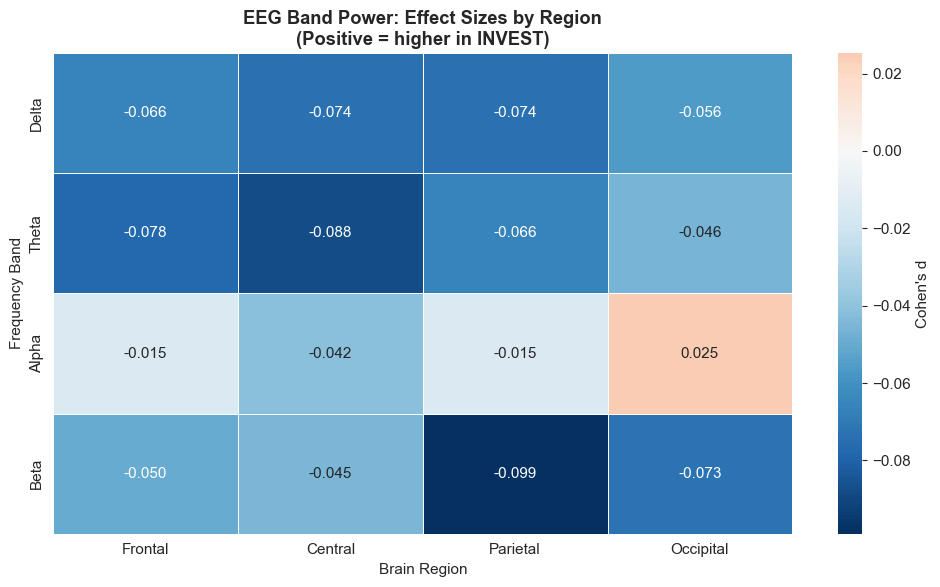


EEG Effects by Frequency Band:
         mean     std     min     max
band                                 
Delta -0.0672  0.0085 -0.0737 -0.0559
Theta -0.0695  0.0177 -0.0878 -0.0464
Alpha -0.0114  0.0276 -0.0416  0.0253
Beta  -0.0669  0.0247 -0.0989 -0.0449

EEG Effects by Brain Region:
             mean     std     min     max
region                                   
Frontal   -0.0521  0.0273 -0.0776 -0.0147
Central   -0.0620  0.0224 -0.0878 -0.0416
Parietal  -0.0634  0.0354 -0.0989 -0.0146
Occipital -0.0376  0.0433 -0.0732  0.0253


In [9]:
if HAS_EEG and len(eeg_results) > 0:
    # Parse EEG feature names to extract band and region
    eeg_results_parsed = eeg_results.copy()
    eeg_results_parsed['band'] = eeg_results_parsed['feature'].apply(lambda x: x.split('_')[1])
    eeg_results_parsed['region'] = eeg_results_parsed['feature'].apply(lambda x: x.split('_')[2])
    
    # Heatmap: bands x regions
    pivot_eeg = eeg_results_parsed.pivot(index='band', columns='region', values='cohens_d')
    
    # Reorder
    band_order = ['Delta', 'Theta', 'Alpha', 'Beta']
    region_order = ['Frontal', 'Central', 'Parietal', 'Occipital']
    pivot_eeg = pivot_eeg.reindex(index=band_order, columns=region_order)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_eeg, cmap='RdBu_r', center=0, annot=True, fmt='.3f',
                cbar_kws={'label': "Cohen's d"}, ax=ax, linewidths=0.5)
    ax.set_xlabel('Brain Region')
    ax.set_ylabel('Frequency Band')
    ax.set_title('EEG Band Power: Effect Sizes by Region\n(Positive = higher in INVEST)', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eeg_band_region_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary by band
    print("\nEEG Effects by Frequency Band:")
    band_summary = eeg_results_parsed.groupby('band')['cohens_d'].agg(['mean', 'std', 'min', 'max'])
    print(band_summary.reindex(band_order).round(4).to_string())
    
    # Summary by region
    print("\nEEG Effects by Brain Region:")
    region_summary = eeg_results_parsed.groupby('region')['cohens_d'].agg(['mean', 'std', 'min', 'max'])
    print(region_summary.reindex(region_order).round(4).to_string())
else:
    print("EEG data not available for detailed analysis")

## 8. Save Results

In [10]:
# Save full results
all_results.to_csv(OUTPUT_DIR / 'feature_divergence_all.csv', index=False)

# Save by modality
for modality in all_results['modality'].unique():
    mod_df = all_results[all_results['modality'] == modality]
    mod_df.to_csv(OUTPUT_DIR / f'feature_divergence_{modality}.csv', index=False)

# Save summary
summary_stats.to_csv(OUTPUT_DIR / 'modality_summary.csv')

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
print(f"  - {OUTPUT_DIR / 'feature_divergence_all.csv'}")
print(f"  - {OUTPUT_DIR / 'modality_summary.csv'}")
print(f"  - {OUTPUT_DIR / 'effect_sizes_by_modality.png'}")
print(f"  - {OUTPUT_DIR / 'top_features_all_modalities.png'}")
print(f"  - {OUTPUT_DIR / 'modality_comparison_summary.png'}")
if HAS_EEG:
    print(f"  - {OUTPUT_DIR / 'eeg_band_region_heatmap.png'}")


FILES SAVED
  - ../../data/results/main/statistical_analyses/feature_divergence/feature_divergence_all.csv
  - ../../data/results/main/statistical_analyses/feature_divergence/modality_summary.csv
  - ../../data/results/main/statistical_analyses/feature_divergence/effect_sizes_by_modality.png
  - ../../data/results/main/statistical_analyses/feature_divergence/top_features_all_modalities.png
  - ../../data/results/main/statistical_analyses/feature_divergence/modality_comparison_summary.png
  - ../../data/results/main/statistical_analyses/feature_divergence/eeg_band_region_heatmap.png


## 9. Key Findings

In [11]:
print("\n" + "="*70)
print("KEY FINDINGS: FEATURE DIVERGENCE BASELINE")
print("="*70)

for modality in all_results['modality'].unique():
    mod_df = all_results[all_results['modality'] == modality]
    strongest = mod_df.loc[mod_df['abs_cohens_d'].idxmax()]
    
    print(f"\n{modality.upper()}:")
    print(f"  Features analyzed: {len(mod_df)}")
    print(f"  Significant (Bonferroni): {mod_df['significant_bonferroni'].sum()}")
    print(f"  Average |d|: {mod_df['abs_cohens_d'].mean():.3f}")
    print(f"  Strongest: {strongest['feature']} (d = {strongest['cohens_d']:.3f})")
    
    direction = 'higher in INVEST' if strongest['cohens_d'] > 0 else 'higher in KEEP'
    print(f"    → {direction}")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


KEY FINDINGS: FEATURE DIVERGENCE BASELINE

PUPIL:
  Features analyzed: 13
  Significant (Bonferroni): 9
  Average |d|: 0.120
  Strongest: pupil_slope_pre (d = -0.303)
    → higher in KEEP

GAZE:
  Features analyzed: 20
  Significant (Bonferroni): 6
  Average |d|: 0.072
  Strongest: gaze_x_std (d = -0.492)
    → higher in KEEP

EEG:
  Features analyzed: 16
  Significant (Bonferroni): 6
  Average |d|: 0.057
  Strongest: eeg_Beta_Parietal (d = -0.099)
    → higher in KEEP

Analysis completed: 2026-04-17 12:07:27
